In [1]:
from pathlib import Path

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
results_fp = Path("./results/geo_elec_scraping_may_2026.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [3]:
results = pd.read_csv(results_fp)
results["Who is correct? (Verified)"].value_counts()

Who is correct? (Verified)
Both       62
Compass    28
Human      10
Name: count, dtype: int64

In [4]:
def compute_scores(row, compass_scores, human_scores):
    correctness = row["Who is correct? (Verified)"]
    ordinance_found = False
    if correctness == "Both":
        if row["Compass Link"] == "Not found":
            compass_scores["does not exist, not found"] += 1
            human_scores["does not exist, not found"] += 1
        else:
            compass_scores["exists, found"] += 1
            human_scores["exists, found"] += 1
            ordinance_found = True
    elif correctness == "Compass":
        if row["Human Link"] == "Not found":  # COMPASS link must exist
            compass_scores["exists, found"] += 1
            human_scores["exists, not found"] += 1
            ordinance_found = True
        elif row["Compass Link"] == "Not found":  # human link exists
            compass_scores["does not exist, not found"] += 1
            human_scores["does not exist, found"] += 1
        else:  # both exist but COMPASS is correct, so human is incorrect
            compass_scores["exists, found"] += 1
            human_scores["exists, incorrectly found"] += 1
            ordinance_found = True
    elif correctness == "Human":
        if row["Compass Link"] == "Not found":  # human link must exist
            compass_scores["exists, not found"] += 1
            human_scores["exists, found"] += 1
            ordinance_found = True
        elif row["Human Link"] == "Not found":  # COMPASS link exists
            compass_scores["does not exist, found"] += 1
            human_scores["does not exist, not found"] += 1
        else:  # both exist but human is correct, so COMPASS is incorrect
            compass_scores["exists, incorrectly found"] += 1
            human_scores["exists, found"] += 1
            ordinance_found = True
    elif correctness == "Neither":
        if row["Compass Link"] == "Not found":
            if row["Human Link"] == "Not found":
                compass_scores["exists, not found"] += 1
                human_scores["exists, not found"] += 1
                ordinance_found = True
            else:  # guess here, assume human is more correct
                compass_scores["exists, not found"] += 1
                human_scores["exists, incorrectly found"] += 1
                ordinance_found = True
        elif row["Human Link"] == "Not found":
            compass_scores["exists, incorrectly found"] += 1
            human_scores["exists, not found"] += 1
            ordinance_found = True
        else:
            compass_scores["exists, incorrectly found"] += 1
            human_scores["exists, incorrectly found"] += 1
            ordinance_found = True
    else:
        msg = f"Unexpected correctness value: {correctness}"
        raise ValueError(msg)

    return ordinance_found


def scores_dict_to_validation_df(scores, truth_labels_col="ordinance_exists"):
    label_to_truth = {
        "exists, found": 1,
        "exists, not found": 1,
        "exists, incorrectly found": 1,
        "does not exist, found": 0,
        "does not exist, not found": 0,
    }

    rows = []
    for score_label, count in scores.items():
        if score_label not in label_to_truth:
            msg = f"Unexpected score label: {score_label}"
            raise ValueError(msg)

        rows.extend(
            {
                "Score": score_label,
                truth_labels_col: label_to_truth[score_label],
            }
            for _ in range(count)
        )

    return pd.DataFrame(rows)

In [5]:
compass_scores = {
    "exists, found": 0,
    "exists, not found": 0,
    "exists, incorrectly found": 0,
    "does not exist, found": 0,
    "does not exist, not found": 0
}
human_scores = {
    "exists, found": 0,
    "exists, not found": 0,
    "exists, incorrectly found": 0,
    "does not exist, found": 0,
    "does not exist, not found": 0
}
ordinance_found = 0

for __, row in results.iterrows():
    ordinance_found += compute_scores(row, compass_scores, human_scores)

assert sum(compass_scores.values()) == len(results)
assert sum(human_scores.values()) == len(results)
print("Number of ordinances found:", ordinance_found)

Number of ordinances found: 45


In [6]:
score_cats = {
    "exists_report": {"exists, found"},
    "exists_no_report": {"exists, not found"},
    "exists_bad_report": {"exists, incorrectly found"},
    "dne_report": {"does not exist, found"},
    "dne_no_report": {"does not exist, not found"},
}

truth_labels_col = "ordinance_exists"

compass_df = scores_dict_to_validation_df(
    compass_scores,
    truth_labels_col=truth_labels_col,
)
out = compute_stats(
    compass_df,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[36  9]
 [ 1 54]]
accuracy=90.00%, precision=85.71%, recall=80.00%, F1=82.76%


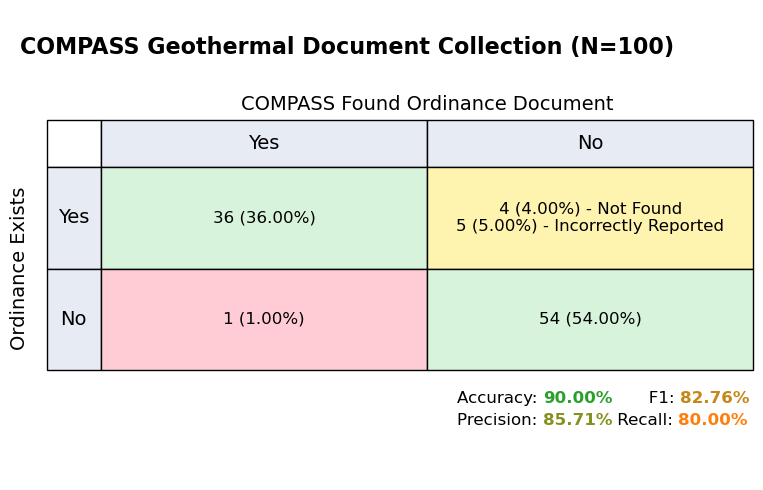

In [8]:
plot_compass_confusion_matrix_from_data(
    compass_df,
    score_cats,
    title="COMPASS Geothermal Document Collection",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Found Ordinance Document",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "geothermal_electricity_scraping_may_2026.png",
    color_scores=True,
)

In [ ]:
human_df = scores_dict_to_validation_df(
    human_scores,
    truth_labels_col=truth_labels_col,
)
human_cm, human_acc, human_precision, human_recall = compute_stats(
    human_df,
    score_cats,
    truth_labels_col=truth_labels_col,
)

print("\nHUMAN")
print("confusion matrix:\n", human_cm)
print(
    f"accuracy={human_acc:.2%}, "
    f"precision={human_precision:.2%}, "
    f"recall={human_recall:.2%}"
)

In [ ]:
plot_compass_confusion_matrix_from_data(
    human_df,
    score_cats,
    title="Human Geothermal Webscraping Validation",
    truth_labels_col=truth_labels_col,
    x_label="Human Retrieved Ordinance",
    y_label="Ordinance Exists",
)